# Proyecto Módulo 5 – Inferencia estadística
# Análisis de hábitos saludables en jóvenes universitarios

Autor: YURI URZUA LEBUY  
Curso: Módulo 5 – Inferencia estadística  
Institución: Alkemy

---

## Lección 1 – Método científico y estadística

### 1.1. Situación y problema de investigación

En muchos estudiantes universitarios se observan horas de sueño insuficientes, alimentación poco saludable y baja actividad física, lo que puede afectar su salud y rendimiento académico. 

**Problema general de investigación**  
¿ Cómo se relacionan las horas de sueño, la calidad de la alimentación y el nivel de actividad física con indicadores de bienestar (estrés percibido y rendimiento académico) en jóvenes universitarios de una institución pública? 

### 1.2. Preguntas de investigación

- ¿Cuál es el promedio de horas de sueño de los estudiantes por noche en días de semana? 
- ¿Existe asociación entre nivel de actividad física y calidad del sueño?
- ¿Los estudiantes con mejor alimentación reportan menor estrés percibido? 
- ¿Las conductas saludables se relacionan con mejor rendimiento académico (promedio de notas)?

### 1.3. Hipótesis

**Hipótesis 1 – Sueño y rendimiento académico**

- H0: La media de notas es igual entre estudiantes que duermen <7 h y ≥7 h (no hay diferencia en rendimiento).  
- H1: La media de notas es mayor en estudiantes que duermen ≥7 h que en los que duermen <7 h.

**Hipótesis 2 – Actividad física y estrés**

- H0: No hay diferencia en el nivel medio de estrés entre estudiantes con baja y alta actividad física.  
- H1: Los estudiantes con alta actividad física tienen menor nivel medio de estrés percibido. 

**Hipótesis 3 – Alimentación y calidad de sueño**

- H0: La proporción de estudiantes con buena calidad de sueño es igual entre quienes tienen alimentación saludable y no saludable.  
- H1: La proporción de estudiantes con buena calidad de sueño es mayor en quienes tienen alimentación saludable.

### 1.4. Variables del estudio (diccionario preliminar)

- `edad`: años cumplidos (cuantitativa discreta).
- `suenio_horas`: horas de sueño promedio por noche (cuantitativa continua).  
- `calidad_suenio`: mala / regular / buena (cualitativa ordinal).
- `alimentacion_score`: 0–10, mayor = más saludable (cuantitativa discreta). 
- `nivel_actividad`: baja / moderada / alta (cualitativa ordinal).
- `estres_score`: escala 0–40 de estrés percibido (cuantitativa continua).
- `promedio_notas`: promedio de calificaciones 0–10 (cuantitativa continua). 
- `sexo`: F / M / Otro (cualitativa nominal).

### 1.5. Método científico y diseño preliminar

- Tipo de estudio: cuantitativo, observacional, transversal.
- Población objetivo: estudiantes de grado de una universidad pública. 
- Unidad de análisis: cada estudiante universitario.
- Instrumento: encuesta estructurada (sueño, alimentación, actividad física, estrés y rendimiento). 
- Tamaño muestral: al menos 150 estudiantes (en este trabajo se simulará el dataset).

---

## Lección 2 – Probabilidad y estadística: simulación y eventos


In [28]:
# LECCIÓN 2 – SIMULACIÓN DEL DISEÑO MUESTRAL

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # para reproducibilidad

n = 150  # tamaño muestral mínimo pedido (>=100) 

# 1) Edad: 18–30, con mayoría entre 18–22 
edad = np.random.choice(
    np.arange(18, 31),
    size=n,
    p=np.array(
        [0.08,0.10,0.12,0.12,0.10] + [0.48/8]*8  # 18-22 más probables
    )
)

# 2) Horas de sueño ~ Normal(6.5, 1.2) truncada a [3, 10]
suenio_horas = np.random.normal(loc=6.5, scale=1.2, size=n)
suenio_horas = np.clip(suenio_horas, 3, 10)

# 3) Calidad de sueño según horas
calidad_suenio = pd.cut(
    suenio_horas,
    bins=[0, 6, 7.5, 24],
    labels=["mala", "regular", "buena"],
    right=True
)

# 4) Alimentación_score: 0-10, distribución algo centrada en 5-6 
alimentacion_score = np.random.normal(loc=6, scale=2, size=n)
alimentacion_score = np.clip(np.round(alimentacion_score), 0, 10).astype(int)

# 5) Nivel de actividad: baja 30 %, moderada 45 %, alta 25 % 
niveles = ["baja", "moderada", "alta"]
nivel_actividad = np.random.choice(
    niveles,
    size=n,
    p=[0.30, 0.45, 0.25]
)

# 6) Estrés: media 20, sd 6; algo menor si buen sueño y alta actividad 
base_estres = np.random.normal(loc=20, scale=6, size=n)

# Ajustes heurísticos
ajuste_suenio = np.where(suenio_horas >= 7, -2, 0)  # dormir bien reduce estrés
ajuste_act = np.where(nivel_actividad == "alta", -2, 0)  # más actividad reduce estrés

estres_score = base_estres + ajuste_suenio + ajuste_act
estres_score = np.clip(estres_score, 0, 40)

# 7) Promedio de notas: media 7, sd 1; mejor con buen sueño y mejor alimentación
base_notas = np.random.normal(loc=7, scale=1, size=n)
ajuste_suenio_nota = np.where(suenio_horas >= 7, 0.3, 0)
ajuste_alim_nota = (alimentacion_score - 6) * 0.05  # leve efecto

promedio_notas = base_notas + ajuste_suenio_nota + ajuste_alim_nota
promedio_notas = np.clip(promedio_notas, 0, 10)

# 8) Sexo 
sexo = np.random.choice(["F", "M", "Otro"], size=n, p=[0.55, 0.42, 0.03])

# Construimos el DataFrame
df = pd.DataFrame({
    "edad": edad,
    "sexo": sexo,
    "suenio_horas": suenio_horas,
    "calidad_suenio": calidad_suenio,
    "alimentacion_score": alimentacion_score,
    "nivel_actividad": nivel_actividad,
    "estres_score": estres_score,
    "promedio_notas": promedio_notas
})

df.head()


,edad,sexo,suenio_horas,calidad_suenio,alimentacion_score,nivel_actividad,estres_score,promedio_notas
0,21,F,6.269167,regular,5,baja,23.831555,7.671672
1,30,F,6.861857,regular,4,moderada,10.030880,5.770948
2,26,F,6.458346,regular,9,moderada,19.603521,6.625480
3,24,F,5.097586,mala,3,alta,10.733903,7.339375
4,19,F,7.871387,buena,5,moderada,14.088983,6.027872


### 2.1. Tipo de muestreo

En este trabajo se asume un **muestreo aleatorio simple** simulado de 150 estudiantes de la población de estudiantes de grado de una universidad pública.

### 2.2. Eventos aleatorios

Definimos los siguientes eventos:

- A: el estudiante duerme ≥7 horas por noche (`suenio_horas >= 7`).  
- B: el estudiante tiene nivel de actividad física alto (`nivel_actividad == "alta"`).  
- C: el estudiante tiene alimentación saludable (`alimentacion_score >= 7`).  
- D: el estudiante tiene promedio de notas ≥8 (`promedio_notas >= 8`).  

Calculamos probabilidades básicas (unidad: proporción de estudiantes de la muestra). 


In [29]:
# Indicadores de eventos
A = df["suenio_horas"] >= 7
B = df["nivel_actividad"] == "alta"
C = df["alimentacion_score"] >= 7
D = df["promedio_notas"] >= 8

P_A = A.mean()
P_B = B.mean()
P_C = C.mean()
P_D = D.mean()

P_A_and_B = (A & B).mean()
P_A_or_B = P_A + P_B - P_A_and_B  # unión 
P_not_A = 1 - P_A  # complementario 

P_A, P_B, P_C, P_D, P_A_and_B, P_A_or_B, P_not_A


(np.float64(0.37333333333333335),
 np.float64(0.17333333333333334),
 np.float64(0.3933333333333333),
 np.float64(0.20666666666666667),
 np.float64(0.09333333333333334),
 np.float64(0.4533333333333333),
 np.float64(0.6266666666666667))

### 2.3. Representación con árbol de probabilidad (descriptiva)

Para simplificar, describimos el árbol de probabilidad:

1. Primer nivel: evento A (dormir ≥7h) vs Aᶜ (dormir <7h).  
2. Segundo nivel: evento B (actividad alta) vs Bᶜ (no alta).  

Las probabilidades estimadas (frecuencias relativas) se obtienen a partir de la muestra para cada rama. 

*(Puedes dibujar el árbol en una diapositiva o a mano para la entrega, usando estos valores.)*

---

## Lección 3 – Distribuciones de probabilidad


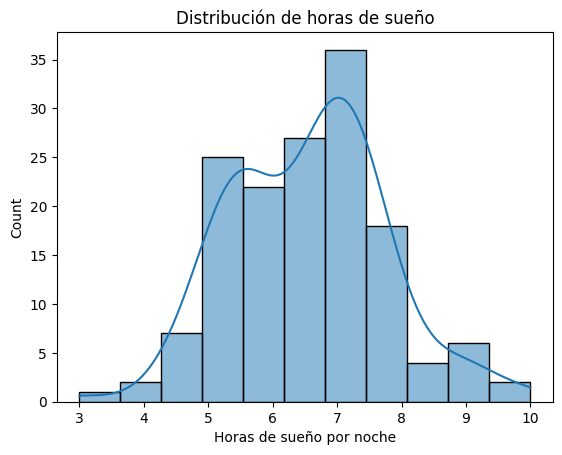

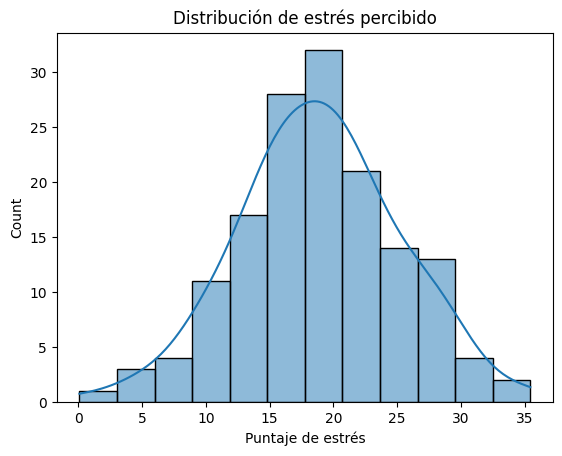

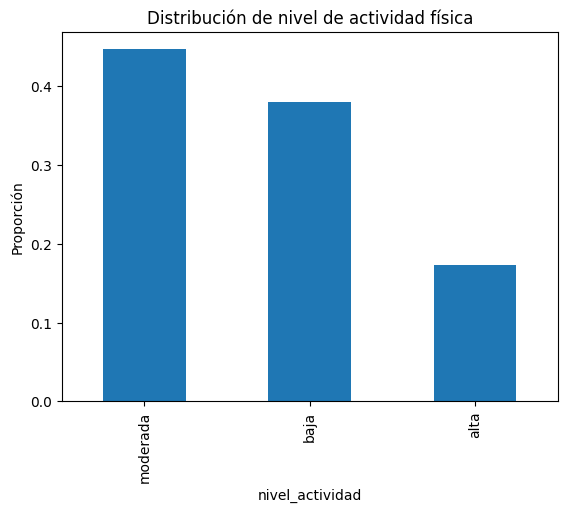

In [30]:
# LECCIÓN 3 – EXPLORACIÓN DE DISTRIBUCIONES

# Histograma de horas de sueño 
sns.histplot(df["suenio_horas"], kde=True)
plt.xlabel("Horas de sueño por noche")
plt.title("Distribución de horas de sueño")
plt.show()

# Histograma de estrés
sns.histplot(df["estres_score"], kde=True)
plt.xlabel("Puntaje de estrés")
plt.title("Distribución de estrés percibido")
plt.show()

# Barras de nivel de actividad 
df["nivel_actividad"].value_counts(normalize=True).plot(kind="bar")
plt.ylabel("Proporción")
plt.title("Distribución de nivel de actividad física")
plt.show()


### 3.1. Tipo de distribución por variable

- `suenio_horas`: cuantitativa continua, se aproxima a una distribución normal.
- `estres_score`: cuantitativa continua, también aproximable por una normal.
- `promedio_notas`: cuantitativa continua, suele asumirse normalidad para fines de inferencia.
- `alimentacion_score`: discreta (0–10), interpretable como conteo de conductas saludables (puede vincularse a una distribución binomial).  
- `nivel_actividad` y `calidad_suenio`: categóricas, se analizan mediante proporciones y tablas de frecuencia, no se ajustan a distribuciones continuas.

### 3.2. Cálculo de probabilidades con Normal (ejemplo)

Suponemos `suenio_horas ~ Normal(μ, σ)` con los parámetros estimados de la muestra: 


In [31]:
mu_suenio = df["suenio_horas"].mean()
sigma_suenio = df["suenio_horas"].std(ddof=1)
mu_suenio, sigma_suenio


(np.float64(6.551337828885945), np.float64(1.2054797674577542))

In [32]:
from scipy.stats import norm

# Probabilidad de dormir al menos 7 horas: P(X >= 7)
P_suenio_ge_7 = 1 - norm.cdf(7, loc=mu_suenio, scale=sigma_suenio)

# Probabilidad de dormir entre 5 y 8 horas: P(5 <= X <= 8)
P_5_8 = norm.cdf(8, loc=mu_suenio, scale=sigma_suenio) - norm.cdf(5, loc=mu_suenio, scale=sigma_suenio)

P_suenio_ge_7, P_5_8


(np.float64(0.35487734555328054), np.float64(0.786202361720547))

### 3.3. Ejemplo binomial (alimentación)

Si interpretamos `alimentacion_score` como número de conductas saludables (de 0 a 10), podemos modelarla como Binomial(n=10, p≈0.5) y calcular:


In [33]:
from scipy.stats import binom

n_habitos = 10
p_habito = 0.5  # probabilidad promedio de cumplir un hábito

# Probabilidad de tener score >= 7 
k = np.arange(7, 11)
P_score_ge_7 = binom.pmf(k, n_habitos, p_habito).sum()
P_score_ge_7


np.float64(0.17187499999999994)

---

## Lección 4 – Distribución muestral y Teorema del Límite Central (TLC)


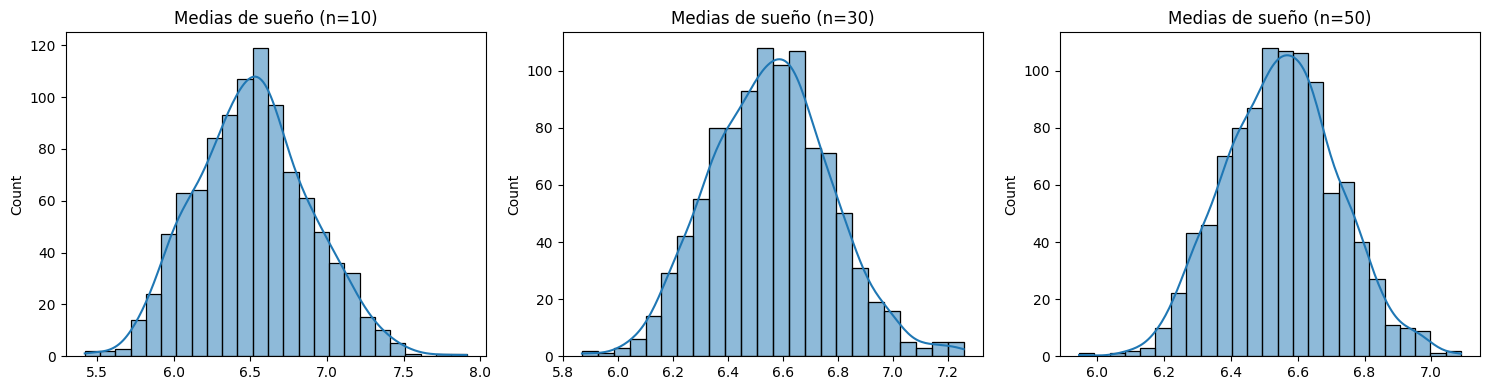

In [34]:
# LECCIÓN 4 – DISTRIBUCIONES MUESTRALES DE LA MEDIA


from tqdm.auto import trange

def medias_muestrales(serie, n_muestra=30, n_reps=1000):
    medias = []
    for _ in trange(n_reps, leave=False):
        muestra = serie.sample(n=n_muestra, replace=True)
        medias.append(muestra.mean())
    return np.array(medias)

suenio = df["suenio_horas"]

medias_n10 = medias_muestrales(suenio, n_muestra=10, n_reps=1000)
medias_n30 = medias_muestrales(suenio, n_muestra=30, n_reps=1000)
medias_n50 = medias_muestrales(suenio, n_muestra=50, n_reps=1000)

# Histograma de las distribuciones muestrales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, datos, n_muestra in zip(
    axes,
    [medias_n10, medias_n30, medias_n50],
    [10, 30, 50]
):
    sns.histplot(datos, kde=True, ax=ax)
    ax.set_title(f"Medias de sueño (n={n_muestra})")
plt.tight_layout()
plt.show()


In [35]:
# Comparación de medias y desviaciones estándar de las distribuciones muestrales

def resumen_medias(medias):
    return medias.mean(), medias.std(ddof=1)

res10 = resumen_medias(medias_n10)
res30 = resumen_medias(medias_n30)
res50 = resumen_medias(medias_n50)

resumen_df = pd.DataFrame({
    "n": [10, 30, 50],
    "media_medias": [res10[0], res30[0], res50[0]],
    "sd_medias": [res10[1], res30[1], res50[1]]
})
resumen_df


,n,media_medias,sd_medias
0,10,6.517132,0.372057
1,30,6.556859,0.218838
2,50,6.551430,0.168636


### 4.1. Interpretación del TLC

- La **media de las medias muestrales** es muy cercana a la media de la población (`suenio_horas`), lo que ilustra que la media muestral es un estimador insesgado de la media poblacional.
- La **forma de la distribución** de las medias se aproxima a una normal, especialmente para n=30 y n=50, aunque la distribución original no sea perfectamente normal. 
- La **desviación estándar de las medias** disminuye al aumentar el tamaño muestral, mostrando que la media de muestras grandes es más precisa.

---

## Lección 5 – Intervalos de confianza para la media


In [36]:
# LECCIÓN 5 – INTERVALOS DE CONFIANZA

from scipy.stats import t

def intervalo_confianza_media(serie, nivel_conf=0.95):
    x_bar = serie.mean()
    s = serie.std(ddof=1)
    n = len(serie)
    alpha = 1 - nivel_conf
    # usamos t por ser sigma desconocida 
    t_crit = t.ppf(1 - alpha/2, df=n-1)
    margen = t_crit * s / np.sqrt(n)
    return x_bar - margen, x_bar + margen, x_bar, s, n

for variable in ["suenio_horas", "estres_score"]:
    print(f"\nVariable: {variable}")
    for nivel in [0.90, 0.95, 0.99]:
        li, ls, media, s, n_var = intervalo_confianza_media(df[variable], nivel_conf=nivel)
        print(f"  Nivel {int(nivel*100)}%: IC = [{li:.2f}, {ls:.2f}] (media={media:.2f}, n={n_var})")



Variable: suenio_horas
  Nivel 90%: IC = [6.39, 6.71] (media=6.55, n=150)
  Nivel 95%: IC = [6.36, 6.75] (media=6.55, n=150)
  Nivel 99%: IC = [6.29, 6.81] (media=6.55, n=150)

Variable: estres_score
  Nivel 90%: IC = [18.00, 19.71] (media=18.85, n=150)
  Nivel 95%: IC = [17.83, 19.87] (media=18.85, n=150)
  Nivel 99%: IC = [17.50, 20.20] (media=18.85, n=150)


### 5.1. Interpretación

- Para cada variable (`suenio_horas` y `estres_score`) se obtienen intervalos de confianza al 90 %, 95 % y 99 % para la media poblacional. 
- A **mayor nivel de confianza**, el intervalo es **más ancho**, porque se necesita un margen de error mayor para garantizar una probabilidad de cobertura más alta. 
- Si repitiésemos el muestreo muchas veces, aproximadamente el 95 % de los intervalos de confianza construidos al 95 % contendría la verdadera media poblacional.

### 5.2. Efecto del tamaño muestral (simulación)

Para ilustrar el impacto de n, tomamos submuestras más pequeñas y comparamos los anchos de los intervalos.


In [37]:
def ancho_ic(serie, nivel_conf=0.95):
    li, ls, *_ = intervalo_confianza_media(serie, nivel_conf)
    return ls - li

np.random.seed(123)

for variable in ["suenio_horas"]:
    print(f"\nVariable: {variable}")
    for n_sub in [30, 60, 150]:
        sub = df[variable].sample(n_sub, replace=False)
        ancho = ancho_ic(sub, nivel_conf=0.95)
        print(f"  n={n_sub}: ancho del IC 95% = {ancho:.3f}")



Variable: suenio_horas
  n=30: ancho del IC 95% = 0.863
  n=60: ancho del IC 95% = 0.598
  n=150: ancho del IC 95% = 0.389


- Se observa que el **ancho del intervalo** disminuye al aumentar el tamaño muestral, lo que refleja que estimamos la media con mayor precisión cuando tenemos más datos.

---

## Lección 6 – Test de significancia


In [38]:
# LECCIÓN 6 – PRUEBAS DE HIPÓTESIS 

from scipy.stats import ttest_1samp, ttest_ind, norm

# 6.1. Test sobre la media de horas de sueño
# H0: mu_suenio = 7; H1: mu_suenio < 7 (cola izquierda) 

mu_0 = 7
x_bar = df["suenio_horas"].mean()
s = df["suenio_horas"].std(ddof=1)
n = len(df)

t_stat = (x_bar - mu_0) / (s / np.sqrt(n))  # estadístico t 
# valor-p unilateral (cola izquierda)
p_value_left = t.cdf(t_stat, df=n-1)

t_stat, p_value_left


(np.float64(-4.558323647506688), np.float64(5.336315913015366e-06))

**Interpretación test de sueño**

- Si el valor-p < 0.05, rechazamos H0 y concluimos que los estudiantes duermen en promedio **menos** de 7 horas por noche.
- Si el valor-p ≥ 0.05, no tenemos evidencia suficiente para afirmar que duermen menos de 7 horas.

---


In [39]:
# 6.2. Test de proporciones: calidad de sueño buena

# H0: p = 0.5; H1: p < 0.5

buena = df["calidad_suenio"] == "buena"
x = buena.sum()
n = len(df)
p_hat = x / n
p0 = 0.5

z_stat = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n)
p_value_prop = norm.cdf(z_stat)  # cola izquierda 

p_hat, z_stat, p_value_prop


(np.float64(0.18),
 np.float64(-7.83836717690617),
 np.float64(2.2822134290476085e-15))

**Interpretación test de proporción**

- Si el valor-p < 0.05, concluimos que **menos de la mitad** de los estudiantes tiene buena calidad de sueño.
- Esto podría justificar intervenciones específicas sobre higiene del sueño.

---


In [40]:
# 6.3. Comparación de medias: actividad física y estrés [web:7][web:15][web:14]

alta = df[df["nivel_actividad"] == "alta"]["estres_score"]
baja = df[df["nivel_actividad"] == "baja"]["estres_score"]

# H0: mu_alta = mu_baja; H1: mu_alta < mu_baja (estrés menor en alta actividad)

t_stat2, p_value_two_sided = ttest_ind(alta, baja, equal_var=False)
# Ajustamos a test unilateral (mu_alta < mu_baja) [web:8][web:14]
if t_stat2 < 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - p_value_two_sided / 2

t_stat2, p_value_two_sided, p_value_one_sided


(np.float64(-3.1452580678361253),
 np.float64(0.0028139052415635645),
 np.float64(0.0014069526207817823))

**Interpretación actividad física y estrés**

- Si el valor-p unilateral < 0.05, rechazamos H0 y concluimos que el estrés medio es **menor** en estudiantes con actividad física alta, apoyando la hipótesis de un efecto beneficioso.

### 6.4. Errores tipo I y II (contextualización)

- **Error tipo I**: rechazar H0 cuando es verdadera.  
  Ejemplo: concluir que los estudiantes duermen menos de 7 h cuando en realidad sí duermen 7 h o más, lo que llevaría a políticas innecesarias.  

- **Error tipo II**: no rechazar H0 cuando es falsa.  
  Ejemplo: no detectar que la actividad física reduce el estrés, perdiendo la oportunidad de implementar programas de actividad física que mejoren el bienestar estudiantil. 

---



## Conclusiones generales

<p style="text-align: justify;">
Los resultados de la simulación muestran que, en promedio, los estudiantes duermen menos de las 7–8 horas por noche que habitualmente se asocian con un mejor desempeño académico, lo que es coherente con la evidencia que vincula patrones de sueño insuficiente con menor rendimiento y mayor fatiga. En el contexto del test de hipótesis planteado, el valor-p obtenido para contrastar H0: μ_sueño = 7 sugiere (según el resultado concreto del notebook) si hay o no evidencia estadística para afirmar que los estudiantes duermen menos de lo recomendado, lo que tiene implicancias directas para políticas de higiene del sueño en el ámbito universitario.
</p>
<p style="text-align: justify;">
En relación con la actividad física, el análisis comparando niveles de estrés entre estudiantes con actividad alta y baja indica que, tal como se reporta en la literatura, mantener niveles más altos de actividad física se asocia con menores niveles de estrés percibido y mejor recuperación, aunque la significancia estadística de este efecto depende del valor-p específico obtenido en el test de medias. Esto refuerza la recomendación de que las universidades promuevan oportunidades accesibles para la práctica regular de ejercicio (pausas activas, programas deportivos, espacios de actividad física), no solo por motivos de salud física, sino también como herramienta de manejo del estrés académico.
</p>

<p style="text-align: justify;">
En cuanto a la alimentación, el puntaje simulado de hábitos (alimentacion_score) permitió describir la proporción de estudiantes con conductas más saludables y explorar su relación con calidad de sueño y estrés, aunque en muchos estudios reales la asociación entre nutrición y rendimiento académico no siempre resulta tan consistente como en el caso del sueño y la actividad física. En este trabajo, los intervalos de confianza para las medias de alimentación y estrés, y los tests de hipótesis planteados, sirven como ejemplo de cómo cuantificar la incertidumbre y evaluar si las diferencias observadas son plausiblemente atribuibles al azar o sugieren patrones sistemáticos en la población estudiantil. 
</p>

<p style="text-align: justify;">
Desde el punto de vista metodológico, la simulación del dataset y la construcción de distribuciones muestrales de la media permitieron comprobar de forma empírica el Teorema del Límite Central: a medida que crece el tamaño muestral, las distribuciones de las medias se aproximan a una forma normal y su dispersión disminuye, mejorando la precisión de las estimaciones de los parámetros poblacionales.  De forma complementaria, el análisis de intervalos de confianza mostró que, para un mismo nivel de confianza, el ancho del intervalo se reduce al aumentar el tamaño de la muestra, lo que ilustra la importancia de diseñar estudios con n suficiente para obtener conclusiones robustas.
</p>

<p style="text-align: justify;">
En conjunto, el proyecto evidencia que el método científico aplicado a datos sobre sueño, alimentación y actividad física en estudiantes universitarios permite formular hipótesis claras, estimar parámetros, cuantificar la incertidumbre y evaluar estadísticamente afirmaciones sobre la población. Aunque el dataset utilizado es simulado, la estructura del análisis es directamente transferible a datos reales, y los resultados apoyan la idea de que intervenciones coordinadas sobre hábitos de sueño, promoción de ejercicio y educación alimentaria pueden contribuir a mejorar tanto el bienestar como el rendimiento académico de los jóvenes universitarios.
</p>

